# CNN reconstruction with k-space data consistency post-processing

## Prepare

In [1]:
#============= Globals ==========
from src.general_utils import prepare_environment
from mri_dl import (
    ModelConfig,
    MRIUndersampledDataset,
    ResidualUNet,
    load_checkpoint,
    predict_numpy_with_data_consistency,
)
from src.metrices import calculate_psnr, calculate_ssim
import torch
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HPC = False

#============= main ==========
prepare_environment(hpc=HPC)

experiment_config = ModelConfig(
    plane="coronal",
    retain_ratio=0.30,
    #epochs=60,
    epochs=2,
    batch_size=32,
    learning_rate=5e-4,
    weight_decay=1e-4,
    random_seed=42,
    num_workers=0 if os.name == "nt" else 4,
    data_consistency_enabled=True,
    per_image_csv_logging=True,
    data_root=Path(os.getcwd() + r"/../undersampled_dataset_split").resolve(),
    result_root=Path(os.getcwd() + r"/../undersampled_results").resolve())

Data path: C:\mri_dataset\brain_age


## Load dataset (created in notebook 05)

In [2]:
test_dataset = MRIUndersampledDataset(
    experiment_config.data_root / "test",
    csv_name="samples.csv",
    plane=experiment_config.plane.capitalize(),
    retain_ratio=experiment_config.retain_ratio,
    load_mask=True,
)

print(f"Test samples: {len(test_dataset)}")

Test samples: 200


## Load a trained delta model

In [3]:
loaded_model, checkpoint = load_checkpoint(
    checkpoint_path=experiment_config.result_dir / "best_model.pt",
    model_class=ResidualUNet,
)

print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])

Best epoch: 51
Best validation loss: 0.024740325659513472


## Run CNN + post-processing on 5 random test samples

In [4]:
num_examples = min(5, len(test_dataset))
if num_examples == 0:
    raise ValueError("test_dataset is empty")

random_indices = torch.randperm(len(test_dataset))[:num_examples].tolist()
examples = []

for idx in random_indices:
    sample = test_dataset[idx]
    row = test_dataset.samples.iloc[idx]

    if "k_space_file" not in row.index or "mask_file" not in row.index:
        raise KeyError("samples.csv must include 'k_space_file' and 'mask_file'. Recreate dataset with notebook 05.")

    k_space_path = test_dataset.split_root / str(row["k_space_file"])
    if not k_space_path.exists():
        raise FileNotFoundError(f"K-space file not found: {k_space_path}")
    mask_path = test_dataset.split_root / str(row["mask_file"])
    if not mask_path.exists():
        raise FileNotFoundError(f"Mask file not found: {mask_path}")

    acquired_k_space = np.load(k_space_path, allow_pickle=False)
    row_mask = np.load(mask_path, allow_pickle=False)

    post = predict_numpy_with_data_consistency(
        model=loaded_model,
        image=sample["input"][0].numpy(),
        acquired_k_space=acquired_k_space,
        row_mask=row_mask,
        return_debug=True,
    )

    volume_name = Path(str(row["resolved_volume_path"])).name if "resolved_volume_path" in row.index else "unknown"
    slice_index = int(row["slice_index"]) if "slice_index" in row.index else -1

    examples.append(
        {
            "idx": idx,
            "volume_name": volume_name,
            "slice_index": slice_index,
            "input": sample["input"][0].numpy(),
            "target": sample["target"][0].numpy(),
            "cnn_reconstruction": post["reconstructed_image"],
            "final_reconstruction": post["final_image"],
            "zero_rows": int(np.count_nonzero(row_mask == 0)),
        }
    )

print(f"Prepared {len(examples)} random samples: {random_indices}")

Prepared 5 random samples: [107, 175, 177, 189, 125]


## Compare the four stages (4 panes per sample)

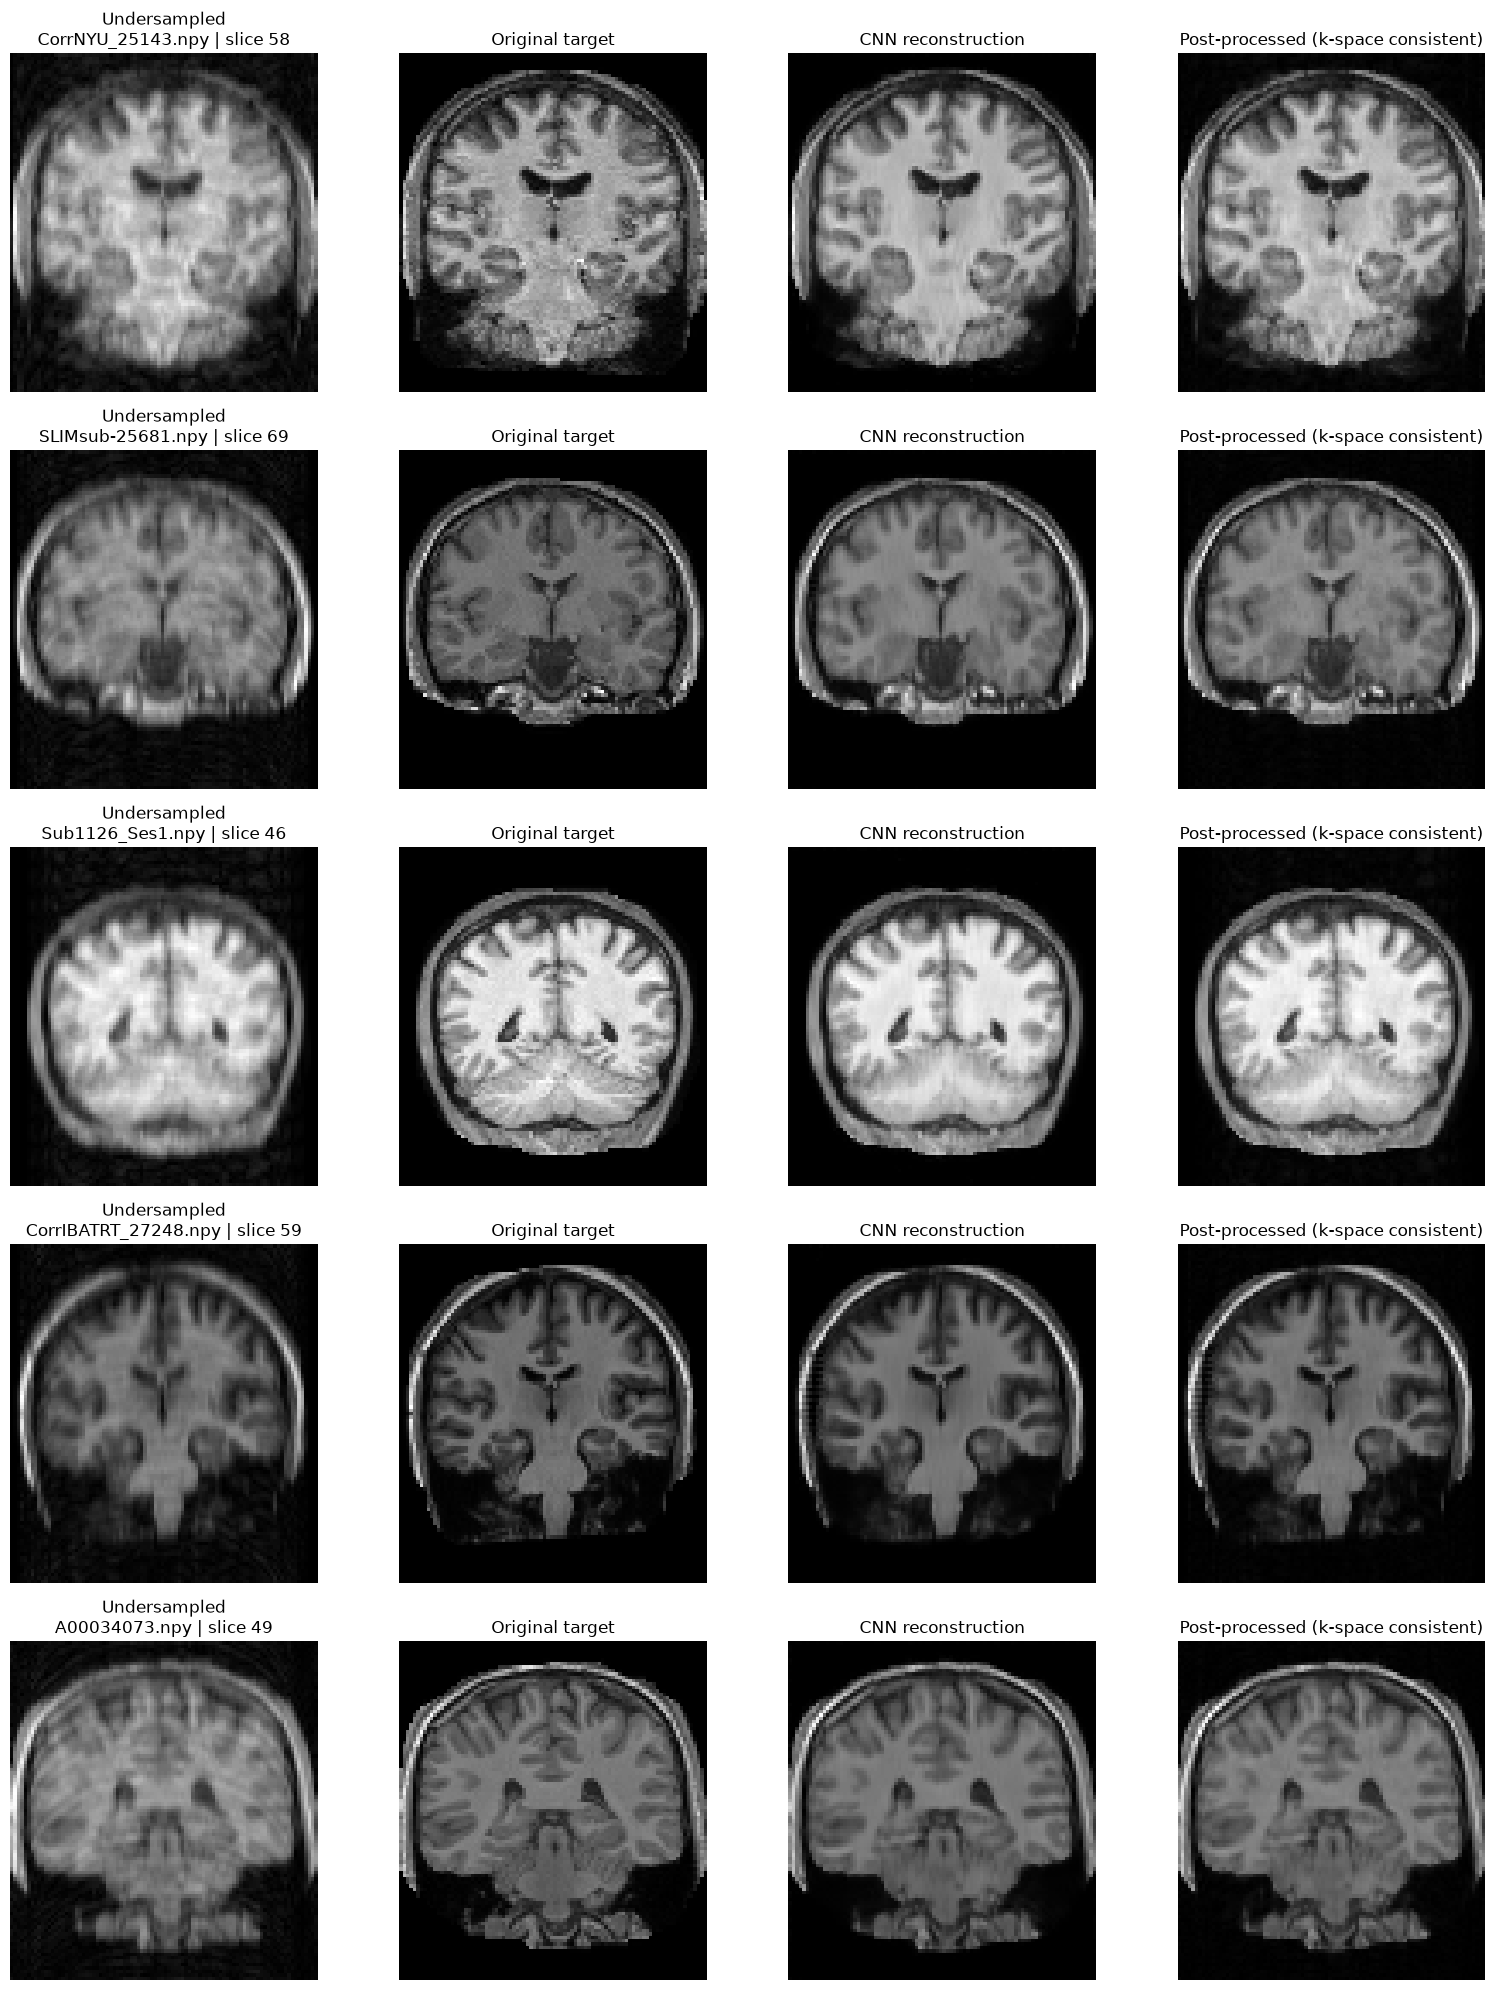

In [5]:
fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))
if len(examples) == 1:
    axes = axes[None, ...]

for row_idx, example in enumerate(examples):
    title_prefix = f"{example['volume_name']} | slice {example['slice_index']}"

    axes[row_idx, 0].imshow(example["input"], cmap="gray")
    axes[row_idx, 0].set_title(f"Undersampled\n{title_prefix}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(example["target"], cmap="gray")
    axes[row_idx, 1].set_title("Original target")
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(example["cnn_reconstruction"], cmap="gray")
    axes[row_idx, 2].set_title("CNN reconstruction")
    axes[row_idx, 2].axis("off")

    axes[row_idx, 3].imshow(example["final_reconstruction"], cmap="gray")
    axes[row_idx, 3].set_title("Post-processed (k-space consistent)")
    axes[row_idx, 3].axis("off")

plt.tight_layout()
plt.show()

## PSNR comparison table

In [6]:
rows = []
for example in examples:
    us_psnr = calculate_psnr(example["target"], example["input"])
    cnn_psnr = calculate_psnr(example["target"], example["cnn_reconstruction"])
    final_psnr = calculate_psnr(example["target"], example["final_reconstruction"])
    us_ssim = calculate_ssim(example["target"], example["input"])
    cnn_ssim = calculate_ssim(example["target"], example["cnn_reconstruction"])
    final_ssim = calculate_ssim(example["target"], example["final_reconstruction"])
    rows.append(
        {
            "Volume": example["volume_name"],
            "Slice": example["slice_index"],
            "Zero rows": example["zero_rows"],
            "US PSNR": us_psnr,
            "CNN PSNR": cnn_psnr,
            "Final PSNR": final_psnr,
            "US SSIM": us_ssim,
            "CNN SSIM": cnn_ssim,
            "Final SSIM": final_ssim,
            "CNN gain vs US": cnn_psnr - us_psnr,
            "Final gain vs US": final_psnr - us_psnr,
            "Final gain vs CNN": final_psnr - cnn_psnr,
            "CNN SSIM gain vs US": cnn_ssim - us_ssim,
            "Final SSIM gain vs US": final_ssim - us_ssim,
            "Final SSIM gain vs CNN": final_ssim - cnn_ssim,
        }
    )

metrics_df = pd.DataFrame(rows)
mean_row = {
    "Volume": "AVERAGE",
    "Slice": "",
    "Zero rows": metrics_df["Zero rows"].mean(),
    "US PSNR": metrics_df["US PSNR"].mean(),
    "CNN PSNR": metrics_df["CNN PSNR"].mean(),
    "Final PSNR": metrics_df["Final PSNR"].mean(),
    "US SSIM": metrics_df["US SSIM"].mean(),
    "CNN SSIM": metrics_df["CNN SSIM"].mean(),
    "Final SSIM": metrics_df["Final SSIM"].mean(),
    "CNN gain vs US": metrics_df["CNN gain vs US"].mean(),
    "Final gain vs US": metrics_df["Final gain vs US"].mean(),
    "Final gain vs CNN": metrics_df["Final gain vs CNN"].mean(),
    "CNN SSIM gain vs US": metrics_df["CNN SSIM gain vs US"].mean(),
    "Final SSIM gain vs US": metrics_df["Final SSIM gain vs US"].mean(),
    "Final SSIM gain vs CNN": metrics_df["Final SSIM gain vs CNN"].mean(),
}
metrics_df = pd.concat([metrics_df, pd.DataFrame([mean_row])], ignore_index=True)

numeric_cols = [
    "Zero rows",
    "US PSNR",
    "CNN PSNR",
    "Final PSNR",
    "US SSIM",
    "CNN SSIM",
    "Final SSIM",
    "CNN gain vs US",
    "Final gain vs US",
    "Final gain vs CNN",
    "CNN SSIM gain vs US",
    "Final SSIM gain vs US",
    "Final SSIM gain vs CNN",
]
for col in numeric_cols:
    metrics_df[col] = metrics_df[col].astype(float)

styled = (
    metrics_df
    .style
    .format(precision=3)
    .highlight_max(
        subset=[
            "Final PSNR",
            "Final gain vs US",
            "Final gain vs CNN",
            "Final SSIM",
            "Final SSIM gain vs US",
            "Final SSIM gain vs CNN",
        ],
        color="lightgreen",
    )
    .hide(axis="index")
)
display(styled)


Volume,Slice,Zero rows,US PSNR,CNN PSNR,Final PSNR,US SSIM,CNN SSIM,Final SSIM,CNN gain vs US,Final gain vs US,Final gain vs CNN,CNN SSIM gain vs US,Final SSIM gain vs US,Final SSIM gain vs CNN
CorrNYU_25143.npy,58,69.000,22.817,24.662,26.521,0.694,0.820,0.849,1.844,3.703,1.859,0.125,0.155,0.029
SLIMsub-25681.npy,69,69.000,23.376,26.982,28.108,0.600,0.917,0.807,3.607,4.732,1.125,0.318,0.208,-0.110
Sub1126_Ses1.npy,46,69.000,21.776,24.315,25.704,0.652,0.906,0.812,2.539,3.928,1.389,0.254,0.160,-0.094
CorrIBATRT_27248.npy,59,69.000,24.958,28.390,30.266,0.706,0.917,0.881,3.432,5.309,1.876,0.211,0.175,-0.037
A00034073.npy,49,69.000,24.046,27.659,29.006,0.682,0.894,0.868,3.613,4.960,1.347,0.212,0.186,-0.026
AVERAGE,,69.000,23.395,26.402,27.921,0.667,0.891,0.843,3.007,4.526,1.519,0.224,0.177,-0.047
